# KDE raster heatmaps
## Imports + parameters

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from dateutil import parser as dtparser

import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep

import osmnx as ox
from sklearn.neighbors import KernelDensity

# ---- Parameters (KDE) ----
CITY_NAME = "Beirut, Lebanon"
MIN_VISIT_MIN = 3              # ignore micro-stops
MERGE_GAP_MIN = 10             # merge same place visits if short gap
DT_CLIP_MAX_MIN = 10           # clamp dt between path points to avoid huge gaps dominating
CELL_M = 100                   # raster resolution (meters per pixel)
BW_VISITS_M = 300              # KDE bandwidth for visit dwell (meters)
BW_MOVE_M = 200                # KDE bandwidth for movement (meters)


## helpers

In [2]:
def parse_geo(s: str):
    s = s.replace("geo:", "")
    lat, lon = s.split(",")
    return float(lat), float(lon)

def duration_minutes(t0, t1):
    return (t1 - t0).total_seconds() / 60.0


## loading json

In [5]:
path = "location-history.json"
with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

print(type(data), len(data))
print("Keys:", data[0].keys())


<class 'list'> 20021
Keys: dict_keys(['endTime', 'startTime', 'visit'])


## Extract visits + timelinePath points

In [6]:
rows_visit, rows_path = [], []

for i, ep in enumerate(data):
    if "startTime" not in ep or "endTime" not in ep:
        continue

    start = dtparser.isoparse(ep["startTime"])
    end   = dtparser.isoparse(ep["endTime"])
    dur = duration_minutes(start, end)
    if dur <= 0:
        continue

    if "visit" in ep:
        v = ep["visit"]
        tc = v.get("topCandidate", {})
        loc = tc.get("placeLocation")
        if loc:
            lat, lon = parse_geo(loc)
            rows_visit.append({
                "episode_id": i,
                "start_time": start,
                "end_time": end,
                "duration_min": dur,
                "lat": lat,
                "lon": lon,
                "place_id": tc.get("placeID"),
                "visit_prob": float(v.get("probability", tc.get("probability", 1.0))),
            })

    if "timelinePath" in ep:
        for p in ep["timelinePath"]:
            plat, plon = parse_geo(p["point"])
            offset_min = float(p.get("durationMinutesOffsetFromStartTime", 0.0))
            t = start + timedelta(minutes=offset_min)
            rows_path.append({
                "episode_id": i,
                "time": t,
                "lat": plat,
                "lon": plon,
            })

visits = pd.DataFrame(rows_visit)
pathpts = pd.DataFrame(rows_path)

print("visits:", len(visits), "pathpts:", len(pathpts))
visits.head()


visits: 6709 pathpts: 66745


,episode_id,start_time,end_time,duration_min,lat,lon,place_id,visit_prob
0,0,2020-02-10 14:25:25+02:00,2020-02-11 06:50:26.122000+02:00,985.018700,33.896096,35.615478,ChIJqbmP24M-HxURAAAAAAAAAAA,0.87
1,2,2020-02-11 07:54:24.665000+02:00,2020-02-11 14:56:37.618000+02:00,422.215883,33.918112,35.617579,ChIJace_C_E-HxUR1jVhXa9WnpQ,0.77
2,4,2020-02-11 15:40:17.483000+02:00,2020-02-12 06:53:03.972000+02:00,912.774817,33.896096,35.615478,ChIJqbmP24M-HxURAAAAAAAAAAA,0.89
3,6,2020-02-12 07:22:35.769000+02:00,2020-02-12 15:02:42.828000+02:00,460.117650,33.918112,35.617579,ChIJace_C_E-HxUR1jVhXa9WnpQ,0.76
4,8,2020-02-12 15:43:38.316000+02:00,2020-02-13 17:29:52.864000+02:00,1546.242467,33.896096,35.615478,ChIJqbmP24M-HxURAAAAAAAAAAA,0.87


## Time parsing + visit cleaning + weights

In [8]:
visits["start_time"] = pd.to_datetime(visits["start_time"], utc=True)
visits["end_time"]   = pd.to_datetime(visits["end_time"],   utc=True)

pathpts["time"] = pd.to_datetime(pathpts["time"], utc=True)

# visits sanity + filter
visits = visits.dropna(subset=["lat", "lon", "duration_min"])
visits = visits[visits["duration_min"] > 0]
visits = visits[visits["duration_min"] >= MIN_VISIT_MIN]

visits["weight"] = visits["duration_min"] * visits["visit_prob"]

# merge repeated same place with small gaps (reduces artificial fragmentation)
visits = visits.sort_values(["start_time"])
visits["prev_place"] = visits["place_id"].shift(1)
visits["prev_end"]   = visits["end_time"].shift(1)
gap = (visits["start_time"] - visits["prev_end"]).dt.total_seconds() / 60.0

merge_mask = (visits["place_id"].notna()) & (visits["place_id"] == visits["prev_place"]) & (gap <= MERGE_GAP_MIN)
visits["group"] = (~merge_mask).cumsum()

visits = (visits.groupby("group", as_index=False)
          .agg({
              "episode_id": "first",
              "start_time": "min",
              "end_time": "max",
              "duration_min": "sum",
              "lat": "first", "lon": "first",
              "place_id": "first",
              "visit_prob": "mean",
              "weight": "sum"
          }))

print("visits after merge:", len(visits))


visits after merge: 6637


## City polygon + GeoDataFrames

In [9]:
city_gdf = ox.geocode_to_gdf(CITY_NAME)
city_poly = city_gdf.geometry.iloc[0]

gvis = gpd.GeoDataFrame(
    visits,
    geometry=[Point(xy) for xy in zip(visits["lon"], visits["lat"])],
    crs="EPSG:4326"
)

gpath = gpd.GeoDataFrame(
    pathpts,
    geometry=[Point(xy) for xy in zip(pathpts["lon"], pathpts["lat"])],
    crs="EPSG:4326"
)


## Project to a metric CRS (single-city assumption) + filter within city

In [10]:
utm_crs = gvis.estimate_utm_crs()

city_m = city_gdf.to_crs(utm_crs)
city_poly_m = city_m.geometry.iloc[0]

gvis_m = gvis.to_crs(utm_crs)
gpath_m = gpath.to_crs(utm_crs)

gvis_m  = gvis_m[gvis_m.within(city_poly_m)]
gpath_m = gpath_m[gpath_m.within(city_poly_m)]

print("gvis_m:", len(gvis_m), "gpath_m:", len(gpath_m))


gvis_m: 1240 gpath_m: 12466


## Build raster grid + polygon mask

In [11]:
minx, miny, maxx, maxy = city_poly_m.bounds

xs = np.arange(minx, maxx, CELL_M)
ys = np.arange(miny, maxy, CELL_M)
xx, yy = np.meshgrid(xs, ys)
grid_points = np.vstack([xx.ravel(), yy.ravel()]).T

prep_poly = prep(city_poly_m)
mask = np.array([prep_poly.contains(Point(p)) for p in grid_points]).reshape(xx.shape)


## KDE for dwell (visits)

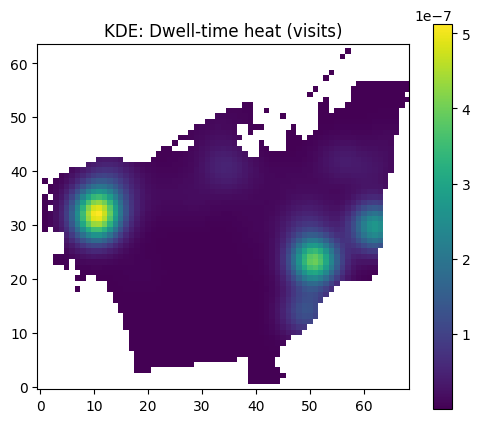

In [12]:
coords = np.vstack([gvis_m.geometry.x.values, gvis_m.geometry.y.values]).T
weights = gvis_m["weight"].values

kde = KernelDensity(bandwidth=BW_VISITS_M, kernel="gaussian")
kde.fit(coords, sample_weight=weights)

dens = np.exp(kde.score_samples(grid_points)).reshape(xx.shape)
dens_visits = np.where(mask, dens, np.nan)

plt.figure(figsize=(6,5))
plt.imshow(dens_visits, origin="lower")
plt.title("KDE: Dwell-time heat (visits)")
plt.colorbar()
plt.show()


## KDE for movement (timelinePath with Δt weights)

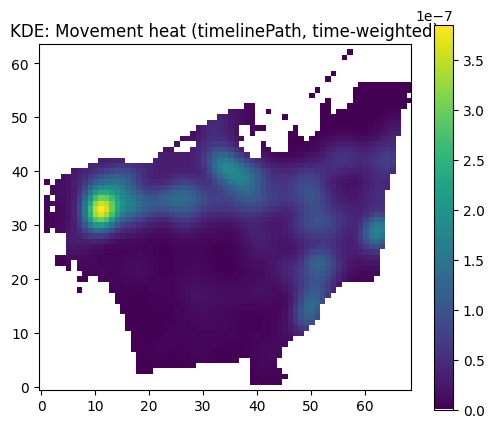

In [13]:
gpath_m = gpath_m.sort_values(["episode_id", "time"])
gpath_m["t_next"] = gpath_m.groupby("episode_id")["time"].shift(-1)

dt_min = (gpath_m["t_next"] - gpath_m["time"]).dt.total_seconds()/60.0
gpath_m["dt_min"] = dt_min.fillna(0).clip(lower=0, upper=DT_CLIP_MAX_MIN)

gpath_m = gpath_m[gpath_m["dt_min"] > 0].copy()
gpath_m["weight"] = gpath_m["dt_min"]

coords_p = np.vstack([gpath_m.geometry.x.values, gpath_m.geometry.y.values]).T
weights_p = gpath_m["weight"].values

kde2 = KernelDensity(bandwidth=BW_MOVE_M, kernel="gaussian")
kde2.fit(coords_p, sample_weight=weights_p)

dens2 = np.exp(kde2.score_samples(grid_points)).reshape(xx.shape)
dens_move = np.where(mask, dens2, np.nan)

plt.figure(figsize=(6,5))
plt.imshow(dens_move, origin="lower")
plt.title("KDE: Movement heat (timelinePath, time-weighted)")
plt.colorbar()
plt.show()


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

points = gpath_p.copy()
if "weight" not in points.columns:
    points["weight"] = 1.0

# Bounds and grid
minx, miny, maxx, maxy = edges.total_bounds

CELL = 80          # meters per pixel (smaller = higher quality but heavier)
BW = 200           # bandwidth in meters (try 150, 250, 400)

xs = np.arange(minx, maxx, CELL)
ys = np.arange(miny, maxy, CELL)
xx, yy = np.meshgrid(xs, ys)
grid = np.vstack([xx.ravel(), yy.ravel()]).T

coords = np.vstack([points.geometry.x.values, points.geometry.y.values]).T
weights = points["weight"].values

kde = KernelDensity(bandwidth=BW, kernel="gaussian")
kde.fit(coords, sample_weight=weights)

dens = np.exp(kde.score_samples(grid)).reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_axis_off()

# intensity surface (extent in the same CRS!)
im = ax.imshow(
    dens,
    extent=[minx, maxx, miny, maxy],
    origin="lower",
    alpha=0.75
)

# vector roads on top
edges.plot(ax=ax, linewidth=0.6, alpha=0.20)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label("Point intensity (KDE density units, weighted)")

ax.set_title("KDE point-intensity field over roads (all points)")
plt.show()


NameError: name 'gpath_p' is not defined